In [68]:
import pandas as pd
import numpy as np
import warnings
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

warnings.filterwarnings("ignore")

In [69]:
CLEAN_PATH = r"C:\\Users\\2539990\\Downloads\\healthcare_cleaned.csv"
df = pd.read_csv(CLEAN_PATH)
df.head()



,Patient Name,Age,Gender,Condition,Medication,Visit Date,Blood Pressure,Cholesterol,Email,Phone Number,Visit_Year,Visit_Month,BP_Systolic,BP_Diastolic,Age_Group,High_Cholesterol,On_Medication
0,David Lee,25,Other,Heart Disease,Metformin,2020-01-15,140/90,200.0,NaN,NaN,2020,1,140.0,90.0,Young,0,1
1,Emily Davis,40,Male,Diabetes,NaN,2020-01-15,120/80,200.0,NaN,NaN,2020,1,120.0,80.0,Adult,0,0
2,Laura Martinez,35,Other,Asthma,Metformin,2020-01-15,110/70,160.0,NaN,NaN,2020,1,110.0,70.0,Adult,0,1
3,Michael Wilson,40,Male,Diabetes,Albuterol,2020-01-15,110/70,180.0,NaN,NaN,2020,1,110.0,70.0,Adult,0,1
4,David Lee,40,Female,Asthma,NaN,2020-01-15,110/70,180.0,NaN,NaN,2020,1,110.0,70.0,Adult,0,0


In [70]:
# ─────────────────────────────────────────────────────────────────────────────
# STYLE
# ─────────────────────────────────────────────────────────────────────────────
PALETTE = ["#4361EE", "#3A0CA3", "#7209B7", "#F72585", "#4CC9F0"]
BG      = "#0D1117"
CARD    = "#161B22"
TEXT    = "#E6EDF3"
MUTED   = "#8B949E"
ACCENT  = "#4361EE"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": CARD,
    "text.color": TEXT, "axes.labelcolor": TEXT,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": "#30363D", "grid.color": "#21262D",
    "grid.linestyle": "--", "grid.alpha": 0.5,
    "font.family": "DejaVu Sans",
})

In [71]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — LOAD & PREPARE DATA
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 65)
print("  STEP 1 │ Load & Prepare Data")
print("=" * 65)

df = pd.read_csv(CLEAN_PATH)
print(f"\n  Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Target : Condition  →  {df['Condition'].unique().tolist()}")

FEATURES = [
    "Age",
    "BP_Systolic",
    "BP_Diastolic",
    "Cholesterol",
    "High_Cholesterol",
    "On_Medication",
    "Visit_Year",
    "Visit_Month",
]

le = LabelEncoder()
df["Condition_Label"] = le.fit_transform(df["Condition"])

X = df[FEATURES].copy()
y = df["Condition_Label"]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\n  Features     : {FEATURES}")
print(f"  Train size   : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Test  size   : {len(X_test):,}   ({len(X_test)/len(X)*100:.0f}%)")
print(f"  Classes      : {le.classes_.tolist()}")
print(f"\n  Class distribution (train):")
train_labels = pd.Series(y_train).map(dict(enumerate(le.classes_)))
print(train_labels.value_counts().to_string())
print(f"\n  Class distribution (test):")
test_labels = pd.Series(y_test).map(dict(enumerate(le.classes_)))

  STEP 1 │ Load & Prepare Data

  Loaded : 995 rows × 17 columns
  Target : Condition  →  ['Heart Disease', 'Diabetes', 'Asthma', 'Hypertension']

  Features     : ['Age', 'BP_Systolic', 'BP_Diastolic', 'Cholesterol', 'High_Cholesterol', 'On_Medication', 'Visit_Year', 'Visit_Month']
  Train size   : 746  (75%)
  Test  size   : 249   (25%)
  Classes      : ['Asthma', 'Diabetes', 'Heart Disease', 'Hypertension']

  Class distribution (train):
Condition_Label
Asthma           310
Heart Disease    155
Diabetes         154
Hypertension     127

  Class distribution (test):


In [72]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — TRAIN MODELS
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  STEP 2 │ Train & Evaluate Models")
print("=" * 65)

MODELS = {
    "Logistic Regression": LogisticRegression(
        max_iter=500, random_state=42, solver="lbfgs"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42
    ),
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results_ml = {}

for name, model in MODELS.items():
    print(f"\n  ── {name} ──")

    # Cross-validation
    cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="accuracy")
    print(f"     10-Fold CV Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Train on full train split, evaluate on held-out test
    model.fit(X_train, y_train)
    y_pred    = model.predict(X_test)
    test_acc  = accuracy_score(y_test, y_pred)
    test_f1   = f1_score(y_test, y_pred, average="weighted")

    print(f"     Test Accuracy       : {test_acc:.4f}")
    print(f"     Weighted F1 Score   : {test_f1:.4f}")

    results_ml[name] = {
        "model":    model,
        "cv_scores": cv_scores,
        "cv_mean":  cv_scores.mean(),
        "cv_std":   cv_scores.std(),
        "test_acc": test_acc,
        "test_f1":  test_f1,
        "y_pred":   y_pred,
    }


  STEP 2 │ Train & Evaluate Models

  ── Logistic Regression ──
     10-Fold CV Accuracy : 0.4151 ± 0.0036
     Test Accuracy       : 0.4137
     Weighted F1 Score   : 0.2421

  ── Random Forest ──
     10-Fold CV Accuracy : 0.3547 ± 0.0431
     Test Accuracy       : 0.3574
     Weighted F1 Score   : 0.2964

  ── Gradient Boosting ──
     10-Fold CV Accuracy : 0.3436 ± 0.0367
     Test Accuracy       : 0.3574
     Weighted F1 Score   : 0.2993


In [73]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — BEST MODEL DETAIL
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  STEP 3 │ Best Model — Detailed Report")
print("=" * 65)

best_name = max(results_ml, key=lambda n: results_ml[n]["test_acc"])
best      = results_ml[best_name]
y_pred    = best["y_pred"]
best_model = best["model"]

print(f"\n  ★ Best model : {best_name}")
print(f"    Test Accuracy : {best['test_acc']:.4f}")
print(f"    Weighted F1   : {best['test_f1']:.4f}")

print("\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Feature importances (tree-based models)
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
    print("  Feature Importances:")
    for feat, imp in fi.items():
        bar = "█" * int(imp * 50)
        print(f"    {feat:<22} {imp:.4f}  {bar}")
else:
    fi = None
    print("  (Logistic Regression — coefficients used for feature importance in chart)")
    coef = pd.DataFrame(
        best_model.coef_,
        index=le.classes_,
        columns=FEATURES
    )
    print("\n  Coefficient matrix (one row per class):")
    print(coef.to_string())
    



  STEP 3 │ Best Model — Detailed Report

  ★ Best model : Logistic Regression
    Test Accuracy : 0.4137
    Weighted F1   : 0.2421

  Classification Report:
               precision    recall  f1-score   support

       Asthma       0.41      1.00      0.59       103
     Diabetes       0.00      0.00      0.00        51
Heart Disease       0.00      0.00      0.00        52
 Hypertension       0.00      0.00      0.00        43

     accuracy                           0.41       249
    macro avg       0.10      0.25      0.15       249
 weighted avg       0.17      0.41      0.24       249

  (Logistic Regression — coefficients used for feature importance in chart)

  Coefficient matrix (one row per class):
                    Age  BP_Systolic  BP_Diastolic  Cholesterol  High_Cholesterol  On_Medication  Visit_Year  Visit_Month
Asthma        -0.034465    -0.036595      0.064530     0.058663          0.025707      -0.061972         0.0          0.0
Diabetes       0.010062     0.27715


  STEP 4 │ Generate ML Dashboard Visualisation

  ✔ ML dashboard generated successfully.


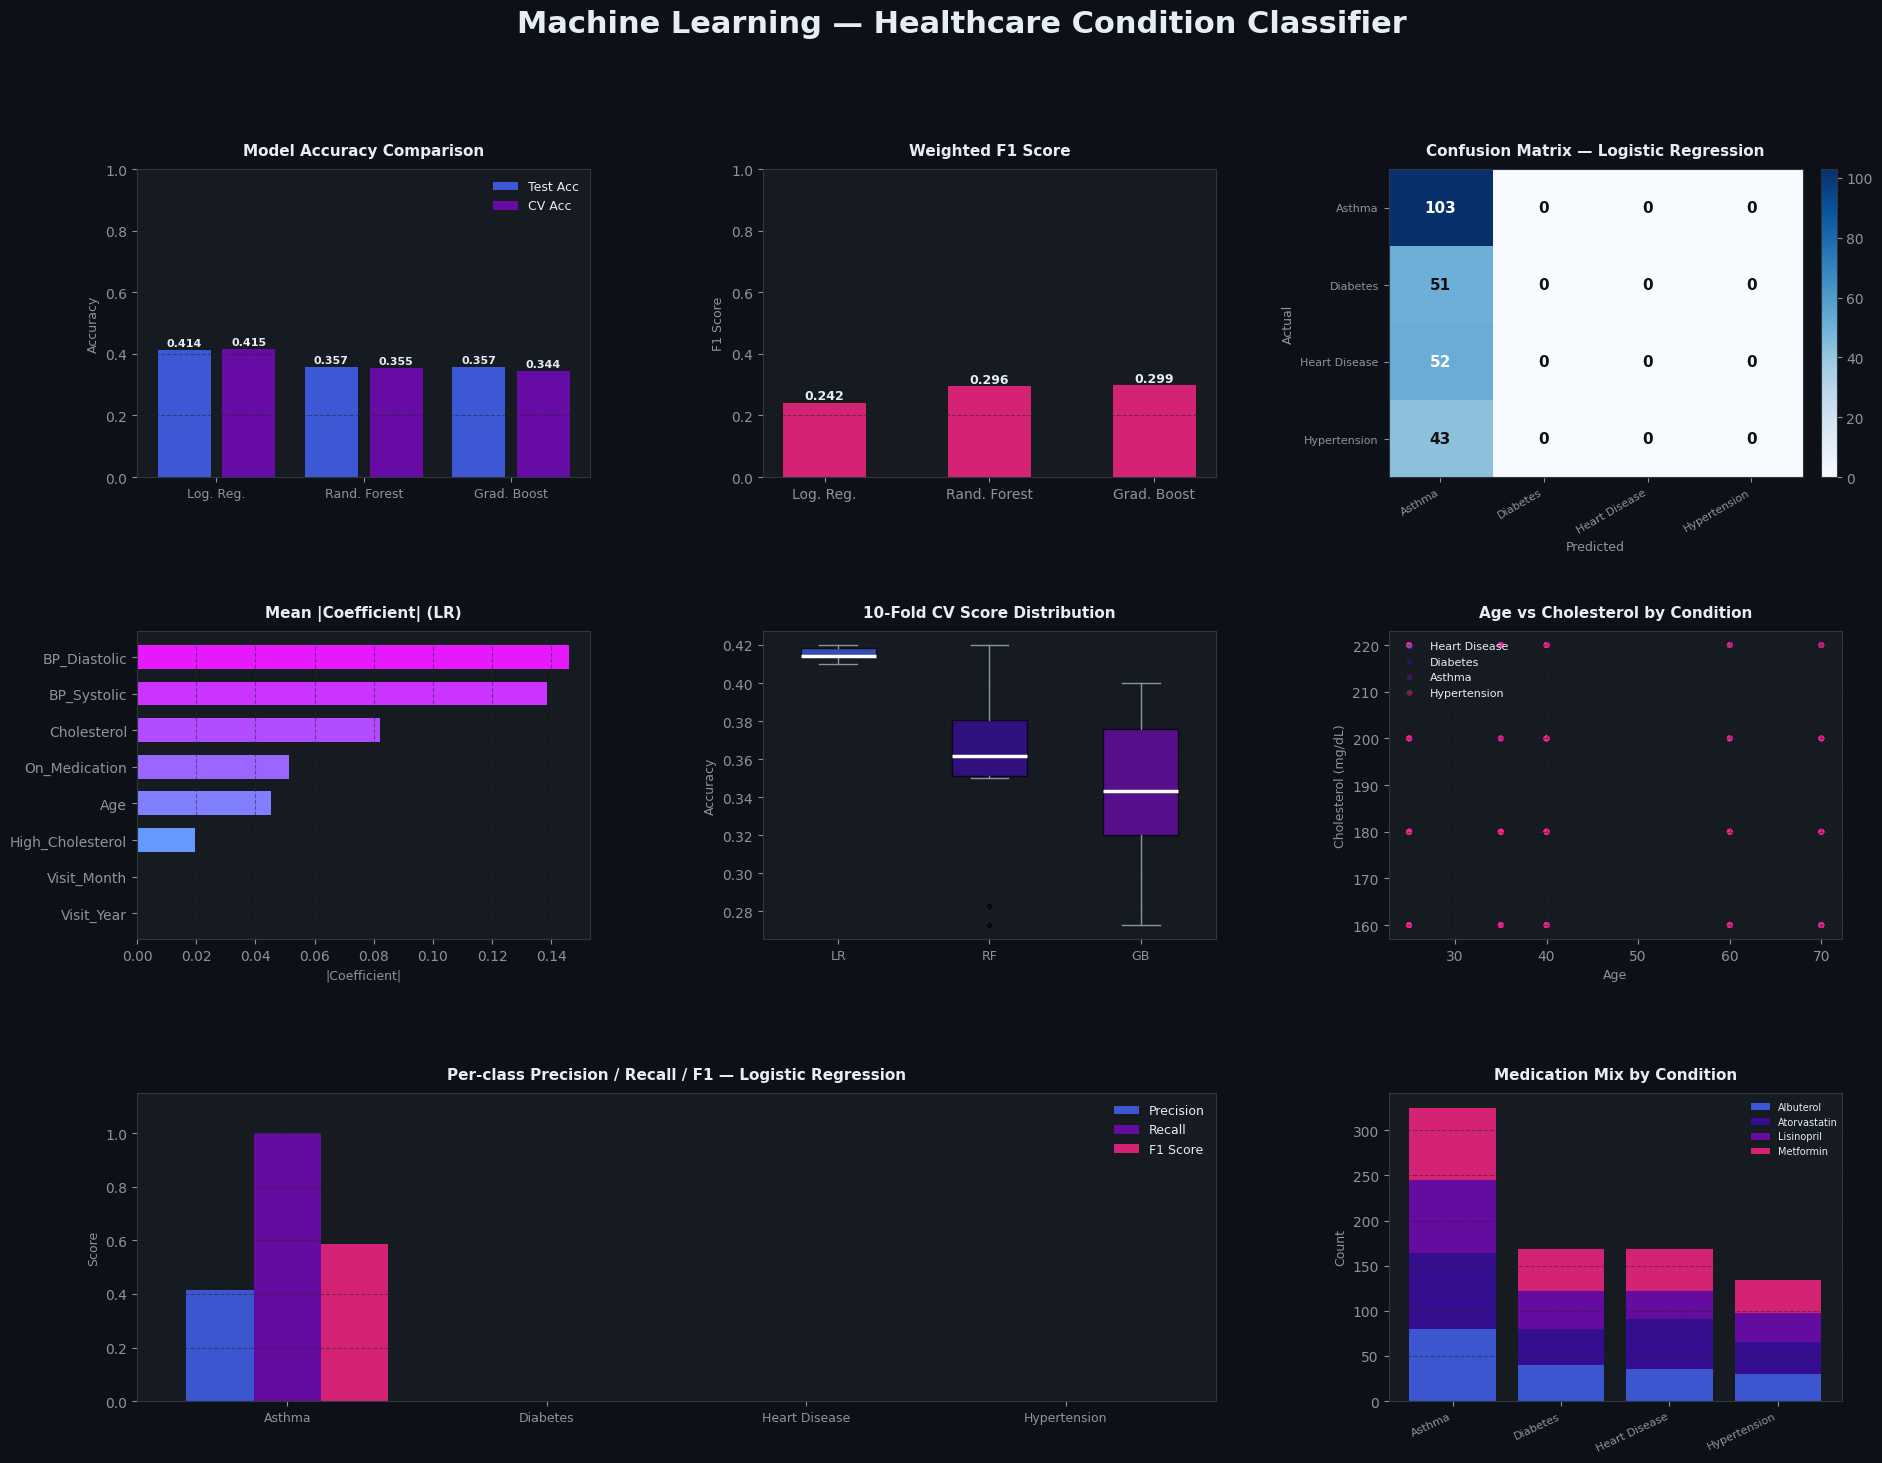

In [80]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  STEP 4 │ Generate ML Dashboard Visualisation")
print("=" * 65)

fig = plt.figure(figsize=(22, 16), facecolor=BG)
fig.suptitle("Machine Learning — Healthcare Condition Classifier",
             fontsize=22, fontweight="bold", color=TEXT, y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

model_names  = list(results_ml.keys())
model_accs   = [results_ml[n]["test_acc"] for n in model_names]
model_cvs    = [results_ml[n]["cv_mean"]  for n in model_names]
model_f1s    = [results_ml[n]["test_f1"]  for n in model_names]
short_labels = ["Log. Reg.", "Rand. Forest", "Grad. Boost"]

# ── Plot 1: Model Accuracy Comparison ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
x_ = np.arange(len(model_names))
ax1.bar(x_ - 0.22, model_accs, width=0.36, color=PALETTE[0],
        label="Test Acc", alpha=0.88, edgecolor="none")
ax1.bar(x_ + 0.22, model_cvs,  width=0.36, color=PALETTE[2],
        label="CV Acc",   alpha=0.88, edgecolor="none")
ax1.set_xticks(x_)
ax1.set_xticklabels(short_labels, fontsize=9)
ax1.set_ylim(0, 1)
ax1.set_title("Model Accuracy Comparison", color=TEXT, pad=10,
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Accuracy", color=MUTED, fontsize=9)
ax1.legend(framealpha=0, fontsize=9)
ax1.grid(axis="y")
for i, (ta, ca) in enumerate(zip(model_accs, model_cvs)):
    ax1.text(i - 0.22, ta + 0.012, f"{ta:.3f}", ha="center",
             color=TEXT, fontsize=8, fontweight="bold")
    ax1.text(i + 0.22, ca + 0.012, f"{ca:.3f}", ha="center",
             color=TEXT, fontsize=8, fontweight="bold")

# ── Plot 2: Weighted F1 Scores ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(short_labels, model_f1s, color=PALETTE[3],
               alpha=0.85, edgecolor="none", width=0.5)
for bar, val in zip(bars, model_f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f"{val:.3f}", ha="center", color=TEXT, fontsize=9, fontweight="bold")
ax2.set_ylim(0, 1)
ax2.set_title("Weighted F1 Score", color=TEXT, pad=10, fontsize=11, fontweight="bold")
ax2.set_ylabel("F1 Score", color=MUTED, fontsize=9)
ax2.grid(axis="y")
fig.tight_layout(rect=[0, 0, 1, 0.96])
# ── Plot 3: Confusion Matrix (best model) ────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test, y_pred)
im = ax3.imshow(cm, cmap="Blues", aspect="auto")
ax3.set_xticks(range(len(le.classes_)))
ax3.set_yticks(range(len(le.classes_)))
ax3.set_xticklabels(le.classes_, rotation=30, ha="right", fontsize=8)
ax3.set_yticklabels(le.classes_, fontsize=8)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax3.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "#111",
                 fontsize=11, fontweight="bold")
ax3.set_title(f"Confusion Matrix — {best_name}", color=TEXT,
              pad=10, fontsize=11, fontweight="bold")
ax3.set_xlabel("Predicted", color=MUTED, fontsize=9)
ax3.set_ylabel("Actual",    color=MUTED, fontsize=9)
fig.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
# ── Plot 4: Feature Importances ──────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
if fi is not None:
    colors_fi = plt.cm.cool(np.linspace(0.2, 0.9, len(fi)))
    ax4.barh(fi.index[::-1], fi.values[::-1],
             color=colors_fi, edgecolor="none", height=0.65)
    for i, (feat, val) in enumerate(zip(fi.index[::-1], fi.values[::-1])):
        ax4.text(val + 0.002, i, f"{val:.3f}", va="center",
                 color=TEXT, fontsize=8)
    ax4.set_title("Feature Importances", color=TEXT, pad=10,
                  fontsize=11, fontweight="bold")
    ax4.set_xlabel("Importance", color=MUTED, fontsize=9)
    ax4.grid(axis="x")
else:
    # Logistic Regression — mean absolute coefficient per feature
    mean_abs_coef = np.abs(best_model.coef_).mean(axis=0)
    fi_lr = pd.Series(mean_abs_coef, index=FEATURES).sort_values()
    ax4.barh(fi_lr.index, fi_lr.values,
             color=plt.cm.cool(np.linspace(0.2, 0.9, len(fi_lr))),
             edgecolor="none", height=0.65)
    ax4.set_title("Mean |Coefficient| (LR)", color=TEXT, pad=10,
                  fontsize=11, fontweight="bold")
    ax4.set_xlabel("|Coefficient|", color=MUTED, fontsize=9)
    ax4.grid(axis="x")
ax5 = fig.add_subplot(gs[1, 1])
for i, (name, res) in enumerate(results_ml.items()):
    ax5.boxplot(
        res["cv_scores"], positions=[i], widths=0.5, patch_artist=True,
        boxprops=dict(facecolor=PALETTE[i], alpha=0.7),
        medianprops=dict(color="white", linewidth=2.5),
        whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED),
        flierprops=dict(marker=".", color=MUTED, markersize=5),
    )
ax5.set_xticks([0, 1, 2])
ax5.set_xticklabels(["LR", "RF", "GB"], fontsize=9)
ax5.set_title("10-Fold CV Score Distribution", color=TEXT, pad=10,
              fontsize=11, fontweight="bold")
ax5.set_ylabel("Accuracy", color=MUTED, fontsize=9)
ax5.grid(axis="y")

# ── Plot 6: Scatter — Age vs Cholesterol coloured by Condition ───────────────
ax6 = fig.add_subplot(gs[1, 2])
for i, cond in enumerate(df["Condition"].unique()):
    mask = df["Condition"] == cond
    ax6.scatter(df[mask]["Age"], df[mask]["Cholesterol"],
                color=PALETTE[i % len(PALETTE)], alpha=0.45,
                s=18, label=cond, edgecolors="none")
ax6.set_title("Age vs Cholesterol by Condition", color=TEXT, pad=10,
              fontsize=11, fontweight="bold")
ax6.set_xlabel("Age", color=MUTED, fontsize=9)
ax6.set_ylabel("Cholesterol (mg/dL)", color=MUTED, fontsize=9)
ax6.legend(fontsize=8, framealpha=0, loc="upper left")
ax6.grid()  
# ── Plot 7: Per-class Precision / Recall / F1 ────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0:2])
from sklearn.metrics import precision_recall_fscore_support
prec, rec, f1, sup = precision_recall_fscore_support(
    y_test, y_pred, labels=range(len(le.classes_))
)
x_cls = np.arange(len(le.classes_))
w = 0.26
ax7.bar(x_cls - w, prec, width=w, color=PALETTE[0], label="Precision", alpha=0.85)
ax7.bar(x_cls,     rec,  width=w, color=PALETTE[2], label="Recall",    alpha=0.85)
ax7.bar(x_cls + w, f1,   width=w, color=PALETTE[3], label="F1 Score",  alpha=0.85)
ax7.set_xticks(x_cls)
ax7.set_xticklabels(le.classes_, fontsize=9)
ax7.set_ylim(0, 1.15)
ax7.set_title(f"Per-class Precision / Recall / F1 — {best_name}",
              color=TEXT, pad=10, fontsize=11, fontweight="bold")
ax7.set_ylabel("Score", color=MUTED, fontsize=9)
ax7.legend(framealpha=0, fontsize=9)
ax7.grid(axis="y")

# ── Plot 8: Medication Mix by Condition ──────────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2])
med_pivot = df.groupby(["Condition", "Medication"]).size().unstack(fill_value=0)
meds      = med_pivot.columns.tolist()
bottom    = np.zeros(len(med_pivot))
for j, med in enumerate(meds):
    ax8.bar(med_pivot.index, med_pivot[med], bottom=bottom,
            label=med, color=PALETTE[j % len(PALETTE)],
            edgecolor="none", alpha=0.85)
    bottom += med_pivot[med].values
ax8.set_title("Medication Mix by Condition", color=TEXT, pad=10,
              fontsize=11, fontweight="bold")
ax8.set_xticklabels(med_pivot.index, rotation=25, ha="right", fontsize=8)
ax8.set_ylabel("Count", color=MUTED, fontsize=9)
ax8.legend(fontsize=7, framealpha=0, bbox_to_anchor=(1.01, 1))
ax8.grid(axis="y")
# plt.close(fig)
# plt.show()
print(f"\n  ✔ ML dashboard generated successfully.")
plt.show()
plt.close(fig)




In [79]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — SUMMARY
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  STEP 5 │ Summary")
print("=" * 65)
print(f"\n  {'Model':<22} {'Test Acc':>10}  {'CV Acc':>10}  {'Weighted F1':>12}")
print("  " + "-" * 58)
for name in model_names:
    r = results_ml[name]
    star = " ★" if name == best_name else ""
    print(f"  {name:<22} {r['test_acc']:>10.4f}  {r['cv_mean']:>10.4f}  {r['test_f1']:>12.4f}{star}")

print(f"\n  Best model  : {best_name}")
print(f"  Note        : Low accuracy reflects the limited feature set in this")
print(f"                synthetic dataset. Real-world improvement would come")
print(f"                from richer clinical features (lab panels, vitals history).")
print("\n  ✔  ML modelling complete.")
print("=" * 65)



  STEP 5 │ Summary

  Model                    Test Acc      CV Acc   Weighted F1
  ----------------------------------------------------------
  Logistic Regression        0.4137      0.4151        0.2421 ★
  Random Forest              0.3574      0.3547        0.2964
  Gradient Boosting          0.3574      0.3436        0.2993

  Best model  : Logistic Regression
  Note        : Low accuracy reflects the limited feature set in this
                synthetic dataset. Real-world improvement would come
                from richer clinical features (lab panels, vitals history).

  ✔  ML modelling complete.
